In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


df = pd.read_csv('BMW sales data (2010-2024) (1) (1).csv')

In [50]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_grouped.index, y=df.values, marker='o', linewidth=2, color='red')
plt.title("Évolution du prix moyen des BMW par année", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Prix moyen (USD)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_grouped.index, rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.index, y=top_models.values, palette='Blues_d')
plt.title("Top 10 modèles BMW les plus vendus", fontsize=16, fontweight='bold')
plt.xlabel("Modèle", fontsize=14)
plt.ylabel("Nombre de ventes", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'df_grouped' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
df_encoded_sample = df_encoded.sample(n=20000, random_state=42)
X_sample = df_encoded_sample[features]
y_sample = df_encoded_sample[target]

scaler = StandardScaler()
X_sample[['Engine_Size_L', 'Price_USD', 'Year', 'Mileage_KM']] = scaler.fit_transform(
    X_sample[['Engine_Size_L', 'Price_USD', 'Year', 'Mileage_KM']]
)

svm = SVC(kernel='rbf', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(svm, X_sample, y_sample, cv=cv, scoring='accuracy')

print("Scores de chaque fold :", scores)
print("Score moyen de cross-validation :", scores.mean())

/var/folders/8z/6r0jj9qs12l8x1x0g4q34dqr0000gn/T/ipykernel_29691/2201842609.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[['Engine_Size_L', 'Price_USD', 'Year', 'Mileage_KM']] = scaler.fit_transform(


Scores de chaque fold : [0.69575 0.6955  0.6955  0.6955  0.6955 ]
Score moyen de cross-validation : 0.69555


In [ ]:
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42
)

svm.fit(X_train, y_train)


y_pred = svm.predict(X_test)


print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[ 563  655]
 [1370 1412]]

Classification report :
              precision    recall  f1-score   support

        High       0.29      0.46      0.36      1218
         Low       0.68      0.51      0.58      2782

    accuracy                           0.49      4000
   macro avg       0.49      0.48      0.47      4000
weighted avg       0.56      0.49      0.51      4000



In [ ]:
X_train_sample = X_train.sample(n=2000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train_sample, y_train_sample)
print("Meilleurs paramètres :", grid.best_params_)

Meilleurs paramètres : {'C': 10, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
best_svm = SVC(C=10, gamma=0.1, kernel='rbf', class_weight='balanced', random_state=42)
best_svm.fit(X_train, y_train)

y_pred = best_svm.predict(X_test)
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[ 562  656]
 [1236 1546]]

Classification report :
              precision    recall  f1-score   support

        High       0.31      0.46      0.37      1218
         Low       0.70      0.56      0.62      2782

    accuracy                           0.53      4000
   macro avg       0.51      0.51      0.50      4000
weighted avg       0.58      0.53      0.54      4000



/var/folders/8z/6r0jj9qs12l8x1x0g4q34dqr0000gn/T/ipykernel_29691/592099382.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clust_sample[['Price_USD', 'Mileage_KM', 'Engine_Size_L', 'Sales_Volume']] = scaler.fit_transform(


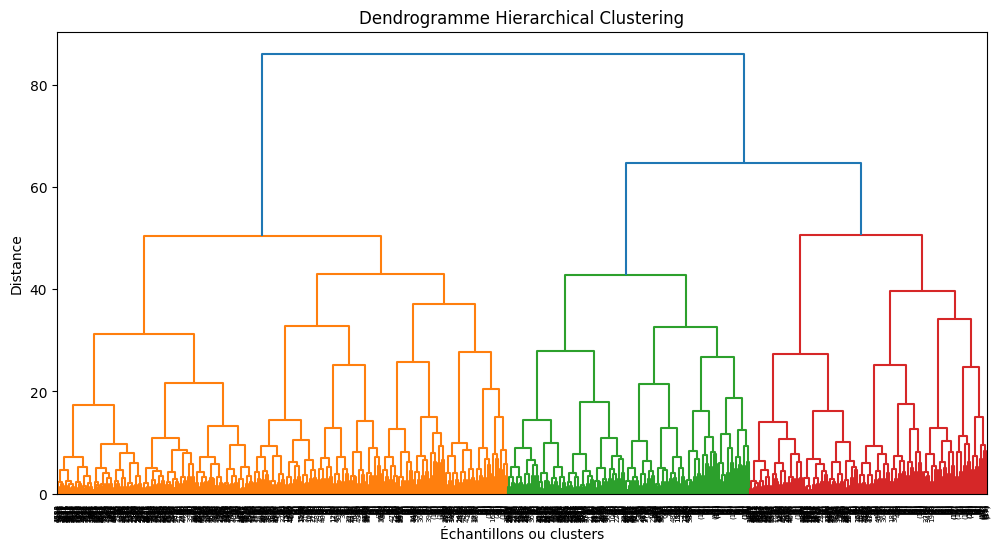

                 Price_USD     Mileage_KM  Engine_Size_L  Sales_Volume  \
Hier_Cluster                                                             
1             78570.905093  108830.123611       3.217546   4830.349074   
2             67075.776772  147061.815988       3.141855   5360.325038   
3             76388.881770   51236.103038       3.326750   5187.353369   

              Fuel_Type  
Hier_Cluster             
1              2.469444  
2              0.633484  
3              0.892338  


In [ ]:
features_clust = ['Price_USD', 'Mileage_KM', 'Engine_Size_L', 'Sales_Volume', 'Fuel_Type']

df_clust = df.copy()
for col in ['Fuel_Type']:
    le = LabelEncoder()
    df_clust[col] = le.fit_transform(df_clust[col])

df_clust_sample = df_clust.sample(n=5000, random_state=42)
X_clust_sample = df_clust_sample[features_clust]

scaler = StandardScaler()
X_clust_sample[['Price_USD', 'Mileage_KM', 'Engine_Size_L', 'Sales_Volume']] = scaler.fit_transform(
    X_clust_sample[['Price_USD', 'Mileage_KM', 'Engine_Size_L', 'Sales_Volume']]
)

linked = linkage(X_clust_sample, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=10, leaf_rotation=90)
plt.title('Dendrogramme Hierarchical Clustering')
plt.xlabel('Échantillons ou clusters')
plt.ylabel('Distance')
plt.show()

labels = fcluster(linked, t=60, criterion='distance')
df_clust_sample['Hier_Cluster'] = labels

print(df_clust_sample.groupby('Hier_Cluster')[features_clust].mean())

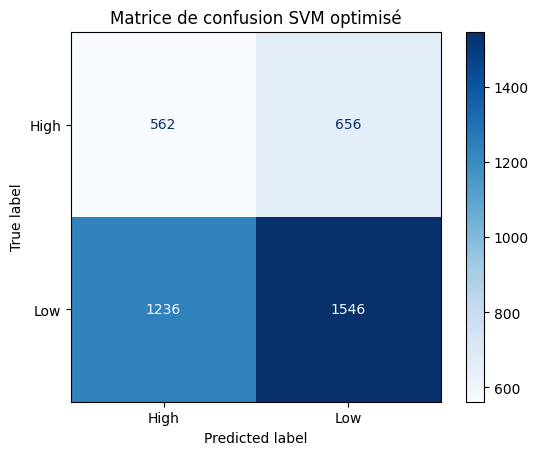

,precision,recall,f1-score,support
High,0.30,0.39,0.34,1218.00
Low,0.69,0.61,0.65,2782.00
accuracy,0.54,0.54,0.54,0.54
macro avg,0.50,0.50,0.49,4000.00
weighted avg,0.57,0.54,0.55,4000.00


Accuracy globale : 54.15%
F1-score macro : 0.49


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion SVM optimisé")
plt.show()

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.style.format("{:.2f}").background_gradient(cmap='YlGnBu'))

print(f"Accuracy globale : {report_dict['accuracy']:.2%}")
print(f"F1-score macro : {report_dict['macro avg']['f1-score']:.2f}")

,Fold,Score
0,1,0.696
1,2,0.696
2,3,0.696
3,4,0.696
4,5,0.696


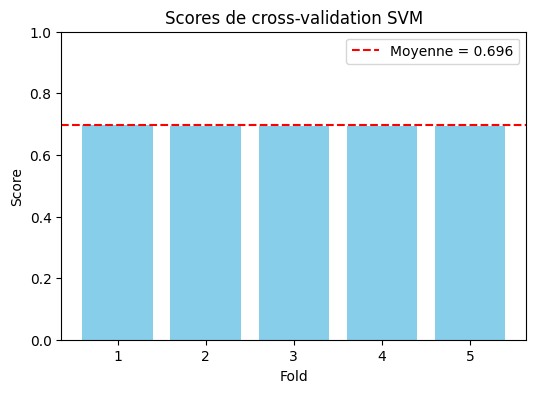

Score moyen de cross-validation : 0.696
Écart-type : 0.000


In [ ]:
scores_df = pd.DataFrame({'Fold': range(1, len(scores)+1), 'Score': scores})

display(scores_df.style.format({'Score': '{:.3f}'}).background_gradient(cmap='YlGnBu'))

plt.figure(figsize=(6,4))
plt.bar(scores_df['Fold'], scores_df['Score'], color='skyblue')
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Moyenne = {scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Scores de cross-validation SVM')
plt.legend()
plt.ylim(0, 1)
plt.show()

print(f"Score moyen de cross-validation : {scores.mean():.3f}")
print(f"Écart-type : {scores.std():.3f}")

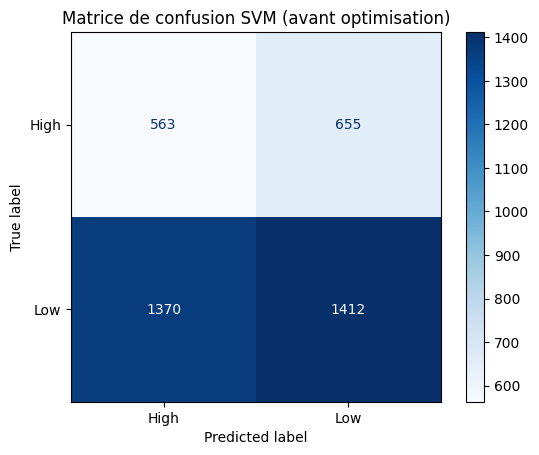

In [ ]:
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion SVM (avant optimisation)")
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

metrics = {
    'Accuracy': [accuracy],
    'F1-score': [f1],
    'Précision ': [precision],
    'Recall ': [recall],
}
metrics_df = pd.DataFrame(metrics)
display(metrics_df.style.format("{:.3f}").background_gradient(cmap='YlGnBu'))

,Accuracy,F1-score,Précision,Recall
0,0.541,0.494,0.498,0.498
